# Extra pre-training for the doctor agent on medical textbooks with Masked Language Modeling (MLM)

Files needed:


*   Textbooks for MLM (we used the textbooks from MedQA)



# Imports

In [ ]:
!pip install datasets

In [ ]:
import torch
import numpy as np
import transformers
from transformers import AutoModelForMaskedLM, AutoTokenizer, Trainer, TrainingArguments, DataCollatorForLanguageModeling
from datasets import load_dataset, Dataset

# Paths

Edit the TEXTBOOKS_PATH variable to match the path of your textbook folder

In [ ]:
# Define the path to your medical textbooks (assuming text format)
TEXTBOOKS_PATH = "./en/"
MODEL_NAME = "microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract"
SAVE_DIR = "./"

# Pre-training

In [ ]:
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.cuda.device_count())  # Number of GPUs available
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))  # Name of the GPU

True
1
Tesla T4


In [ ]:
import os

def load_texts(TEXTBOOKS_PATH, max_words=128):
    """Loads medical textbooks from a folder of text files and splits long lines."""
    texts = []
    for filename in os.listdir(TEXTBOOKS_PATH):
        if filename.endswith(".txt"):
            file_path = os.path.join(TEXTBOOKS_PATH, filename)
            with open(file_path, "r", encoding="utf-8") as f:
                lines = f.readlines()
                processed_lines = []
                for line in lines:
                    line = line.strip()
                    if not line:
                        continue
                    words = line.split()
                    if len(words) <= max_words:
                        processed_lines.append(line)
                    else:
                        # Split into multiple chunks of `max_words` words
                        for i in range(0, len(words), max_words):
                            chunk = words[i:i + max_words]
                            chunk_text = " ".join(chunk)
                            processed_lines.append(chunk_text)

                texts.extend(processed_lines)
                print(f"Loaded {len(processed_lines)} lines from {file_path}")

    return Dataset.from_dict({"text": texts})

# Load dataset from medical textbooks
dataset = load_texts(TEXTBOOKS_PATH)
print(dataset)

Loaded 6779 lines from ./en/First_Aid_Step2.txt
Loaded 4260 lines from ./en/First_Aid_Step1.txt
Loaded 14404 lines from ./en/Pharmacology_Katzung.txt
Loaded 12587 lines from ./en/Surgery_Schwartz.txt
Loaded 22956 lines from ./en/Obstentrics_Williams.txt
Loaded 7828 lines from ./en/Histology_Ross.txt
Loaded 12565 lines from ./en/Cell_Biology_Alberts.txt
Loaded 13456 lines from ./en/Psichiatry_DSM-5.txt
Loaded 4817 lines from ./en/Biochemistry_Lippincott.txt
Loaded 10084 lines from ./en/Anatomy_Gray.txt
Loaded 12100 lines from ./en/Pathology_Robbins.txt
Loaded 26663 lines from ./en/Gynecology_Novak.txt
Loaded 9542 lines from ./en/Physiology_Levy.txt
Loaded 5306 lines from ./en/Pathoma_Husain.txt
Loaded 9796 lines from ./en/Immunology_Janeway.txt
Loaded 20828 lines from ./en/Neurology_Adams.txt
Loaded 8704 lines from ./en/Pediatrics_Nelson.txt
Loaded 49660 lines from ./en/InternalMed_Harrison.txt
Dataset({
    features: ['text'],
    num_rows: 252335
})


In [ ]:
# Load tokenizer and model
already_tokenized = True

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForMaskedLM.from_pretrained(MODEL_NAME)

if already_tokenized:
    tokenized_dataset = Dataset.load_from_disk("tokenized_dataset")
else:
    # Tokenize the dataset
    tokenized_dataset = dataset.map(
        lambda x: tokenizer(x['text'], truncation=True, padding='max_length', max_length=128),
        batched=True,
        num_proc=4  # Use 4 cores for faster tokenization
    )

    # Save the tokenized dataset to disk
    tokenized_dataset.save_to_disk("tokenized_dataset")

mlm_proba = 0.15
data_collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=True, mlm_probability=mlm_proba)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Some weights of the model checkpoint at microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Move model to GPU
model.to(device)

training_losses = []
training_accuracies = []
steps = []

In [ ]:
def compute_metrics(eval_pred, global_step):
    """Computes MLM accuracy during training."""
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    valid_labels = labels != -100  # Ignore masked positions
    correct = (predictions == labels) & valid_labels
    accuracy = correct.sum() / valid_labels.sum()

    training_accuracies.append(accuracy)
    steps.append(global_step)
    return {"mlm_accuracy": accuracy}

# Custom callback to store loss values
from transformers import TrainerCallback
class LossTracker(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and "loss" in logs:
            training_losses.append(logs["loss"])

In [ ]:
from transformers import Trainer
import torch
from transformers.trainer_utils import EvalLoopOutput
from tqdm.auto import tqdm
import numpy as np

class CPUEvalTrainer(Trainer):
    def evaluation_loop(
        self,
        dataloader,
        description,
        prediction_loss_only=None,
        ignore_keys=None,
        metric_key_prefix: str = "eval",
    ):
        # Move model to CPU for evaluation
        self.model.to("cpu")
        self.model.eval()

        preds_host = None
        labels_host = None
        losses_host = None

        all_losses = []
        all_preds = []
        all_labels = []

        for step, inputs in enumerate(tqdm(dataloader, desc=description)):
            # Move all inputs to CPU
            inputs = {k: v.to("cpu") for k, v in inputs.items() if isinstance(v, torch.Tensor)}

            with torch.no_grad():
                outputs = self.model(**inputs)

                loss = outputs.loss
                logits = outputs.logits
                labels = inputs.get("labels")

                if loss is not None:
                    all_losses.append(loss.cpu().numpy())
                if logits is not None:
                    all_preds.append(logits.cpu().numpy())
                if labels is not None:
                    all_labels.append(labels.cpu().numpy())

        # Move model back to GPU after evaluation
        self.model.to("cuda")

        # Format results
        metrics = {}
        if all_preds and all_labels:
            predictions = np.concatenate(all_preds, axis=0)
            label_ids = np.concatenate(all_labels, axis=0)
            if self.compute_metrics is not None:
                metrics = self.compute_metrics((predictions, label_ids))
        if all_losses:
            metrics[f"{metric_key_prefix}_loss"] = np.mean(all_losses)

        return EvalLoopOutput(predictions=predictions, label_ids=label_ids, metrics=metrics, num_samples=len(dataloader.dataset))


In [ ]:
import os

lr = 5e-5
train_dataset, eval_dataset = tokenized_dataset.train_test_split(test_size=0.0008).values()

# Reset losses and accuracies
training_losses = []
training_accuracies = []
steps = []

folder_path = "./lr_" + str(lr) + "/"
os.makedirs(folder_path, exist_ok=True)

training_args = TrainingArguments(
    per_device_train_batch_size=8,  # Increase if GPU memory allows
    per_device_eval_batch_size=2,  # Or even 2 if OOM continues
    eval_accumulation_steps=2,  # Try increasing if needed
    fp16=True,  # Enables mixed precision training (reduces memory usage & speeds up)
    dataloader_num_workers=4,  # Helps with data loading on Colab
    output_dir=folder_path,
    learning_rate=lr,
    overwrite_output_dir=True,
    num_train_epochs=3,
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=1000,  # Adjust based on dataset size
    evaluation_strategy="steps",  # Or "epoch"
    eval_steps=1000,               # Frequency of evaluation (same as logging_steps)
    weight_decay=0.01,
    push_to_hub=False,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,  # tokenized_datasets is moved to GPU automatically if model is on GPU
    eval_dataset=eval_dataset,
    data_collator=data_collator,
    tokenizer=tokenizer,
    compute_metrics=lambda p: compute_metrics(p, trainer.state.global_step)  # Pass global_step to compute_metrics
)
trainer.add_callback(LossTracker())

# Start training
trainer.train()

# Save final model
model.save_pretrained(folder_path)
tokenizer.save_pretrained(folder_path)

print(f"Finished training model with lr : {lr}")

# Save losses & accuracies for visualization
np.save(f"{SAVE_DIR}/training_losses.npy", np.array(training_losses))
np.save(f"{SAVE_DIR}/training_accuracies.npy", np.array(training_accuracies))
np.save(f"{SAVE_DIR}/steps.npy", np.array(steps))

print("Full training complete!")

/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1611: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(
<ipython-input-9-e97619b700a7>:52: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, pl

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Step,Training Loss,Validation Loss,Mlm Accuracy
1000,1.995400,1.873017,0.636790
2000,2.000800,nan,0.649469
3000,1.998900,nan,0.626192
4000,1.988500,1.803214,0.636842
5000,1.982100,1.673225,0.648871
6000,1.960900,1.751064,0.640182
7000,1.952800,2.004212,0.624185
8000,1.935800,nan,0.646106
9000,1.930200,nan,0.636044
10000,1.940400,nan,0.650866


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Finished training model with lr : 5e-05
Full training complete!


Save the optimal model weights to use as the base for Doctor Agents

In [ ]:
!zip -r ./lr_5e-05/epoch3.zip ./lr_5e-05/checkpoint-94551/

  adding: lr_5e-05/checkpoint-94551/ (stored 0%)
  adding: lr_5e-05/checkpoint-94551/optimizer.pt (deflated 9%)
  adding: lr_5e-05/checkpoint-94551/tokenizer_config.json (deflated 74%)
  adding: lr_5e-05/checkpoint-94551/model.safetensors (deflated 7%)
  adding: lr_5e-05/checkpoint-94551/vocab.txt (deflated 54%)
  adding: lr_5e-05/checkpoint-94551/training_args.bin (deflated 51%)
  adding: lr_5e-05/checkpoint-94551/rng_state.pth (deflated 25%)
  adding: lr_5e-05/checkpoint-94551/scheduler.pt (deflated 56%)
  adding: lr_5e-05/checkpoint-94551/special_tokens_map.json (deflated 42%)
  adding: lr_5e-05/checkpoint-94551/scaler.pt (deflated 60%)
  adding: lr_5e-05/checkpoint-94551/config.json (deflated 48%)
  adding: lr_5e-05/checkpoint-94551/trainer_state.json (deflated 82%)
  adding: lr_5e-05/checkpoint-94551/tokenizer.json (deflated 71%)


# Visualization

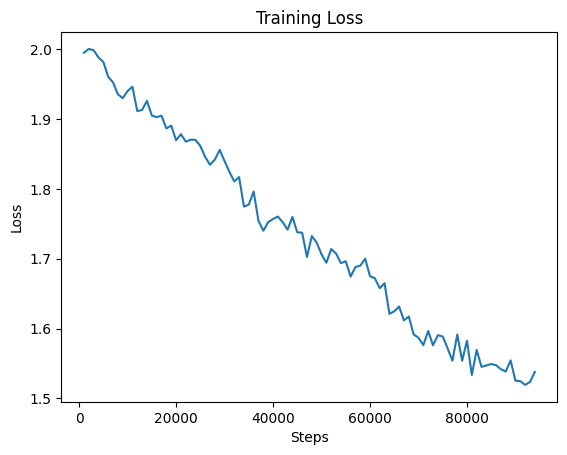

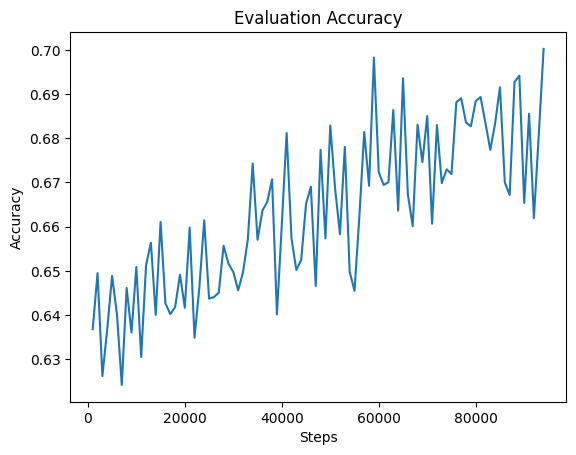

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

steps = np.arange(1000, 95000, 1000)
plt.plot(steps, training_losses, label="lr : " + str(lr))

plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Training Loss")
name = "/training_loss_lr_" + str(lr) + "_epoch" + str(training_args.num_train_epochs) + ".png"
plt.savefig(SAVE_DIR + name)
plt.show()


steps = np.arange(1000, 95000, 1000)
plt.plot(steps, training_accuracies, label="lr : " + str(lr))

plt.xlabel("Steps")
plt.ylabel("Accuracy")
plt.title("Evaluation Accuracy")
name = "/eval_accuracy_lr_" + str(lr) + "_epoch" + str(training_args.num_train_epochs) + ".png"
plt.savefig(SAVE_DIR + name)
plt.show()